# Numerically minimising Pauli-weight

One frequently cited goal when designing an encoding $\mathcal{E}$ is to minimise the average number of Pauli-operators in the terms of the qubit Hamiltonian. This measure is known as the _Pauli-weight_ of the Hamiltonian. 

This might make you think that we should try to find an encoding which minimises the Pauli-weight of indiviaul fermionic operators, for ternary tree encodings, we can show the JKMN encoding gives the minimal average Pauli-weight for fermionic operators. However, often we want to represent terms of a specific Hamiltonian, which contain more than on operator. The product of two operators with high Pauli-weight might have a low Pauli-weight!


## Defining Pauli-weight

Consider the set of majorana operators $\set{\gamma}$. With $P(x)$ being the Pauli-weight of $x$,

$$P_{E}(\mathcal{E}) = \frac{\sum_{\{\gamma\}}{P(\gamma_i)}}{|\set{\gamma}|}$$

If we have a specific Hamiltonian in mind, say the electronic structure hamiltonian, 

$$H_f = \sum_{i,j} \alpha_{i,j} a_i^{\dagger}a_j + \sum_{i,j,k,l} \alpha_{i,j,k,l} a_i^{\dagger}a_j^{\dagger}a_k a_l$$

we can define the Pauli weight the set of Hamiltonian terms $\{h\}$ which result from encoding terms of the fermionic Hamiltonian ($a_i^{\dagger}a_j$ and $a_i^{\dagger}a_j^{\dagger}a_k a_l$). Note that we don't need to consider the Hamiltonian coefficents $\{\alpha_{i,j}, \alpha_{i,j,k,l}\}$ associated to each of those operators, so this Pauli-weight is _system independent_.

$$P_{H}(\mathcal{E}, H_f) = \frac{\sum_{\set{h}}P(h)}{|\set{h}|}$$

When considering a real system (such as a water molecule), many of the terms of the fermionic Hamiltonian will represent transitions which are not allowed. As a result, some terms of the general qubit Hamiltonian will not be needed. 

This isn't the end of the story however, because the specific set of qubit operator terms which have non-zero coefficients depends on which operators in the encoding represent which fermionic operators (an _enumeration_scheme_). Accounting for this, we have the _system dependent_ Pauli-weight:

$$P_{S}(\mathcal{E}_{f}, H_Q) = \frac{\sum_{h\in H_Q}P(h)}{|H_Q|}$$


First we'll import data we need specific to the water molecule.

In [12]:
import json
import numpy as np
import ferrmion as fr
import matplotlib.pyplot as plt

from pathlib import Path

def integrals():
    folder = Path.cwd().joinpath(Path("../../../python/tests/"))
    with open(folder.joinpath("./data/h2o_6-31g.json"), "rb") as file:
        data = json.load(file)
    return np.array(data["ones"]), np.array(data["twos"])
ones, twos = integrals()
n_modes = ones.shape[0]
tree = fr.TernaryTree(n_modes)

encodings: dict[str, fr.MajoranaEncoding] = {
    "jw":fr.JordanWigner(n_modes), 
    "pe":fr.ParityEncoding(n_modes), 
    "bk":fr.BravyiKitaev(n_modes), 
    "jkmn":fr.JKMN(n_modes), 
    "MaxNTO":fr.MaxNTO(n_modes)
    }    

def plot_ps(distributions, *, naive=None, annealed_weight=None, topphatt_weight=None):
    fig, axs = plt.subplots()
    pos = {name: pos for pos,name in enumerate(encodings.keys())}

    for name, dist in distributions.items():
        axs.violinplot(dist, [pos[name]])
    axs.set_xticks([*range(len(encodings))], labels=[*encodings.keys()])

    for name in encodings:
        if naive:
            axs.hlines(naive[name], pos[name] - 0.25, pos[name] + 0.25, linestyles=":", color="black")
        if annealed_weight:
            axs.hlines(
                annealed_weight[name][0],
                pos[name] - 0.25,
                pos[name] + 0.25,
                linestyles="-.",
                color="black",
            )
        if name == "MaxNTO":
            continue
        if topphatt_weight:
            axs.hlines(
                topphatt_weight[name][0],
                pos[name] - 0.25,
                pos[name] + 0.25,
                linestyles="--",
                color="black",
            )

    handles = []
    if naive:
        naive_line = mlines.Line2D(
            [], [], color="black", linestyle=":", label="Naive Enumeration"
        )
        handles.append(naive_line)
    if annealed_weight:
        anneal_line = mlines.Line2D(
            [], [], color="black", linestyle="-.", label="Simulated Annealing"
        )
        handles.append(anneal_line)
    if topphatt_weight:
        topphatt_line = mlines.Line2D([], [], color="black", linestyle="--", label="TOPP-HATT")
        handles.append(topphatt_line)
        
    axs.legend(handles=handles)

    plt.title("$P_S$ Weight of $H_2O$ (STO-3G)")
    plt.show()

## $P_{E}$

In [2]:
import numpy as np

def encoding_weight(encoding: fr.MajoranaEncoding):
    symplectics = encoding.symplectic_matrix
    x_block, z_block = np.hsplit(symplectics, 2)
    operator_weights = np.sum(np.bitwise_or(x_block, z_block), axis=1)
    return operator_weights

In [3]:
ham_indep = {name: encoding_weight(encoding) for name, encoding in encodings.items()}

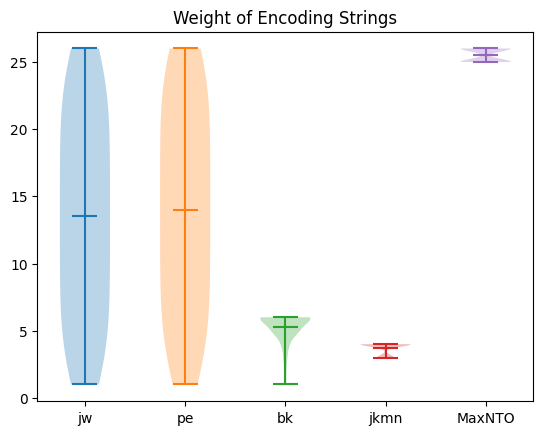

In [4]:
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
fig, axs = plt.subplots()
pos = 0
for dist in ham_indep.values():
    axs.violinplot(dist, [pos], showmeans=True)
    pos += 1

axs.set_xticks([*range(len(ham_indep))], labels=ham_indep.keys())
plt.title("Weight of Encoding Strings")
plt.show()

So it seems there is a clear benefit to the multi-branch Bravyi-kitaev and JKMN (minimum height) trees!

Let's move on to see how these encodings behave when applied to the electronic structure Hamiltonian.

## $P_{H}$

We can find the hamiltonian weight by setting every term of the hamiltonian to 1, so that all the terms are included, and able to cancel eachother out.

In [5]:
import numpy as np
from ferrmion.optimize import pauli_weight

def hamiltonian_term_weights(encoding: fr.MajoranaEncoding, hamiltonian: fr.FermionHamiltonian):
    weights = []
    for i in range(hamiltonian.n_modes):
        for j in range(i, hamiltonian.n_modes):
            # Process each term in the Hamiltonian
            pterm = encoding.encode_fermion_product("+-", [i,j],1)
            weights.append(pauli_weight(pterm)[0])
            for k in range(j, hamiltonian.n_modes):
                for l in range(k, hamiltonian.n_modes):
                    pterm = encoding.encode_fermion_product("++--", [i,j,k,l],1)
                    weights.append(pauli_weight(pterm)[0])
    return np.array(weights)


ones, twos = np.ones((n_modes, n_modes)), np.ones((n_modes, n_modes, n_modes, n_modes))
fham = fr.molecular_hamiltonian(ones, twos, physicist_notation=True)

ham_dep = {
    name: hamiltonian_term_weights(encoding, fham) 
    for name, encoding in encodings.items()
    }

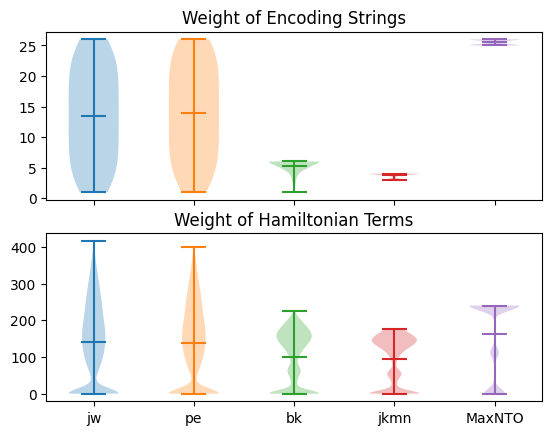

In [6]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 1, sharex=True, sharey=False)
pos = 0
for k in ham_dep.keys():
    axs[0].violinplot(ham_indep[k], [pos], showmeans=True)
    axs[1].violinplot(ham_dep[k], [pos], showmeans=True)
    pos += 1
axs[0].title.set_text("Weight of Encoding Strings")
axs[1].title.set_text("Weight of Hamiltonian Terms")
axs[1].set_xticks([*range(len(ham_dep))], labels=ham_dep.keys())
plt.show()

How interesting! The Bravyi-Kitaev and JKMN encodings have lost a lot of their advantage now that we're considering the application of encodings to Hamiltonian terms.

Conversely, the k-NTO encoding now performs much more similarly to the ternary trees. 

For a specific fermionic system, say a water molecule, some of the hamiltonian coefficients will be zero, and others might cancel eachother out after they have been encoded as Pauli operators.

Since we can give any labels we want to fermionic modes (molecular orbitals of water), it might be possible to assign these so that out hamiltonian terms have the lowest possible Pauli-weight.

## $P_{S}$

Let's start by finding $P_{S}$ for a set of random permutations of the fermionic mode labels.

We'll run each encoding with 250 different enumerations of the fermionic modes. We can generate random permutations and pass them to `.batch_pauli_weights`, which returns both the Pauli-weight and coefficient Pauli-weight together.

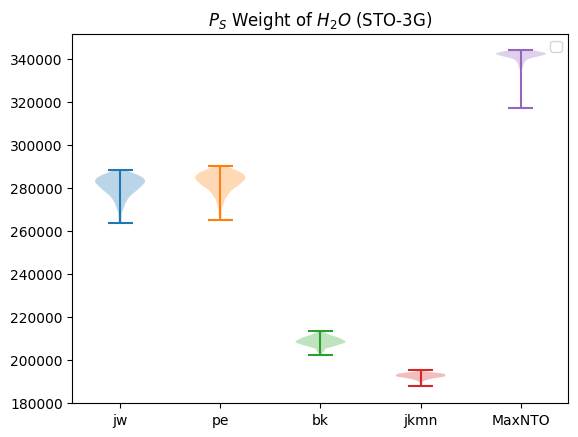

In [ ]:
ones, twos = integrals()
fham = fr.molecular_hamiltonian(ones, twos, physicist_notation=True)

rng = np.random.default_rng(0)
permutations = rng.permuted(
    np.tile(np.arange(n_modes, dtype=np.uintp), (250, 1)), axis=1
)
distributions = {
    name: encoding.batch_pauli_weights(fham, permutations)[0]
    for name, encoding in encodings.items()
}

plot_ps(distributions)

It looks like $P_S$ varies quite a lot depending on the enumeration scheme we use. 

## Optimising $P_S$

Since we've seen that the enumeration scheme can have an effect on the Pauli-weight, we coudl try to optimise this to get a lower Pauli-weight. This should make our quantum circuits smaller and therefore more accurate!

First, let's find the weight of the _naive_ enumerations, the standard form of the encodings as they were first developed.

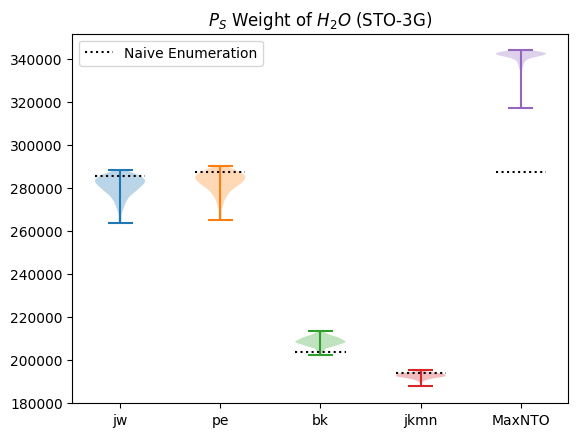

In [ ]:
naive = {}
for name, encoding in encodings.items():
    naive[name] = pauli_weight(encoding.encode(fham))

plot_ps(distributions, naive=naive)

For the Ternary Tree encodings (Jordan-Wigner, Parity, Bravyi-Kitaev andJKMN), the naive enumeration seems to generally be one of the worst options. Interestingly, the naive enumeration is by far the best ofr MaxNTO. 

Let's try a numerical approach to optimise these, and see if we can get better values for the ternary trees.

### Simulated Annealing

First, let's try optimising all of these with simualted annealing. 

Note we're annealing to minimise the Pauli-weight. If you're ineterested, try adding the `coefficient_weighted=True` flag below to see what happens when we minimise the coefficient scaled Pauli-weight.

In [9]:
annealed_weight = {}
for name, encoding in encodings.items():
    print(f"Annealing {name.upper()}")
    annealed_weight[name] = pauli_weight(encoding.encode_annealed(fham)[0])
annealed_weight

Annealing JW
Annealing PE
Annealing BK
Annealing JKMN
Annealing MAXNTO


{'jw': [np.int64(277288)],
 'pe': [np.int64(269529)],
 'bk': [np.int64(200208)],
 'jkmn': [np.int64(189748)],
 'MaxNTO': [np.int64(250470)]}

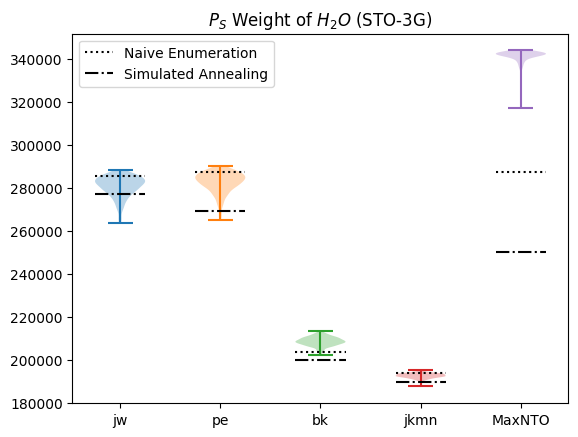

In [13]:
plot_ps(distributions, naive=naive, annealed_weight=annealed_weight)

### TOPP-HATT

For ternary-trees, we can apply the Topology-Preserving Hamiltonian-Adaptive Ternary Tree (TOPP-HATT) method to reduce the Pauli-weight.

Note this doesn't work for the MaxNTO encoding, which is not based on a ternary tree data structure.

In [14]:
trees = {
    "jw": fr.TernaryTree.jordan_wigner(n_modes),
    "pe": fr.TernaryTree.parity(n_modes),
    "bk": fr.TernaryTree.bravyi_kitaev(n_modes),
    "jkmn": fr.TernaryTree.jkmn(n_modes),
    "MaxNTO": None,  # MaxNTO is not based on a ternary tree
}
topphatt_weight = {}
for name, tree in trees.items():
    if tree is not None:
        topphatt_weight[name] = pauli_weight(tree.encode_topphatt(fham)[0])
    else:
        topphatt_weight[name] = None

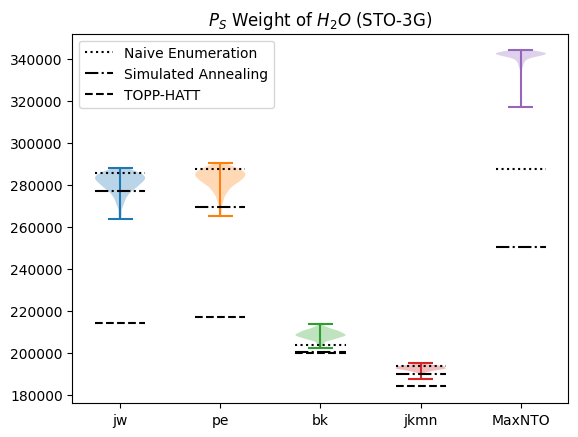

In [15]:
plot_ps(distributions, naive=naive, annealed_weight=annealed_weight, topphatt_weight=topphatt_weight)